# Visium spatial transcriptomics processing

Loads per-sample 10x Visium data, performs QC and filtering, normalizes expression, merges it with stiffness measurements, and exports data for downstream Random Forest regression and differential expression (DE) analysis.

Edit the **Parameters** cell below with your own paths/settings, then run all cells.

In [24]:
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import os
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

## Parameters

Set your paths and thresholds here. This is the only cell you should need to edit.

In [ ]:
# --- Input paths ---
# One sample ID per line, no header
samples_csv = Path('../Inputs/sample_list.csv')

# Root folder containing '<sample>/outs/filtered_feature_bc_matrix.h5' for each sample
visium_data_dir = Path('') #Download the Visium dataset and specify the folder here

# Output of Measurements_processing.ipynb (filtered stiffness measurements)
stiffness_measurements_tsv = Path('../Inputs/filtered_measurements.tsv')

# --- Output paths ---
raw_adata_path = Path("")
normalized_adata_path = Path("")
normalized_merged_tsv = Path("")
figures_dir = Path("")
de_output_dir = Path("")

# --- QC / filtering settings ---
counts_upper_quantile = 0.99   # spots above this quantile of total_counts are removed as likely artifacts
min_genes_per_spot = 200      # sc.pp.filter_cells threshold
min_spots_per_gene = 10       # sc.pp.filter_genes threshold

# --- Stiffness settings ---
stiffness_upper_bound = 12500  # measurements above this value are dropped as outliers

# Stiffness cutoffs used to define ECM_low / ECM_high groups for DE analysis
# (here: 1x, 2x, and 3x the approximate median stiffness)
de_thresholds = [260, 520, 780]

In [26]:
# function adapted from the cell2location tutorial 
# Kleshchevnikov, V., Shmatko, A., Dann, E. et al. Cell2location maps fine-grained cell types in spatial transcriptomics. Nat Biotechnol (2022).
def read_and_qc(sample_name, path):
    r""" This function reads the data for one 10X spatial experiment into the anndata object.
    It also calculates QC metrics. Modify this function if required by your workflow.

    :param sample_name: Name of the sample
    :param path: path to data
    """

    adata = sc.read_visium(os.path.join(path, str(sample_name), 'outs'),
                           count_file='filtered_feature_bc_matrix.h5', load_images=True)
    adata.obs['sample'] = sample_name
    adata.var['SYMBOL'] = adata.var_names
    adata.var.drop(columns='gene_ids', inplace=True)
    adata.var_names_make_unique()
    
    # Calculate QC metrics
    from scipy.sparse import csr_matrix
    adata.X = adata.X.toarray()
    adata.X = csr_matrix(adata.X)
    #also account for genes with MTRNR
    adata.var['mt'] = [gene.startswith('MT') for gene in adata.var['SYMBOL']]
    adata.obs['mt_frac'] = adata[:, adata.var['mt'].tolist()].X.sum(1).A.squeeze()/adata.obs['total_counts']
    #detect ribosomal genes
    adata.var['rp'] = [gene.startswith('RP') for gene in adata.var['SYMBOL']]
  
    # add sample name to obs names
    adata.obs["sample"] = [str(i) for i in adata.obs['sample']]
    adata.obs_names = adata.obs["sample"] + '_' + adata.obs_names
    adata.obs.index.name = 'spot_id'

    return adata
def select_slide(adata, s, s_col='sample'):
    r""" This function selects the data for one slide from the spatial anndata object.

    :param adata: Anndata object with multiple spatial experiments
    :param s: name of selected experiment
    :param s_col: column in adata.obs listing experiment name for each location
    """

    slide = adata[adata.obs[s_col].isin([s]), :]
    s_keys = list(slide.uns['spatial'].keys())
    s_spatial = np.array(s_keys)[[s in k for k in s_keys]][0]

    slide.uns['spatial'] = {s_spatial: slide.uns['spatial'][s_spatial]}

    return slide

## Load Visium samples

In [ ]:
# Read the list of spatial experiments. We renamed the tissue_positions.csv to tissue_positions_list.csv in /spatial
sample_data = pd.read_csv(samples_csv, names=['Sample'])
# Read the data into anndata objects
slides = []
for i in sample_data['Sample']:
    slides.append(read_and_qc(i, path=visium_data_dir))

In [60]:
adata = slides[0].concatenate(
    slides[1:],
    batch_key="sample",
    uns_merge="unique",
    batch_categories=sample_data['Sample'],
    index_unique=None)
# Exclude MT genes
adata.obsm['mt'] = adata[:, adata.var['mt'].values].X.toarray()
adata = adata[:, ~adata.var['mt'].values]

In [32]:
adata.obs.head()

,in_tissue,array_row,array_col,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,mt_frac
spot_id,,,,,,,,,,,,,
Patient01_AAACAAGTATCTCCCA-1,1,50,102,Patient01,1193,7.085064,2352.0,7.763446,30.357143,41.369048,53.146259,70.535714,0.092687
Patient01_AAACACCAATAACTGC-1,1,59,19,Patient01,857,6.754604,1753.0,7.469654,34.740445,47.689675,60.581860,79.634912,0.101540
Patient01_AAACAGGGTCTATATT-1,1,47,13,Patient01,587,6.376727,1079.0,6.984716,35.681186,48.934198,64.133457,91.936979,0.099166
Patient01_AAACATTTCCCGGATT-1,1,61,97,Patient01,2563,7.849324,8835.0,9.086590,33.401245,46.655348,57.792869,71.397849,0.030221
Patient01_AAACCGGGTAGGTACC-1,1,42,28,Patient01,1524,7.329750,3566.0,8.179481,31.379697,43.325855,54.374649,71.284352,0.076556


## QC

In [61]:
# Add barcode column
#index_series = adata.obs.index.to_series()
# Split the index by '_' and extract relevant parts

#split_parts = index_series.str.split('_', expand=True)
# Combine LM ID with suffix after 'count_'
#barcode = split_parts[1] + '_' + split_parts[3]
# Remove 'lane1' if present in the resulting string
adata.obs['Barcode']  = adata.obs.index.to_series()

(0.0, 10000.0)

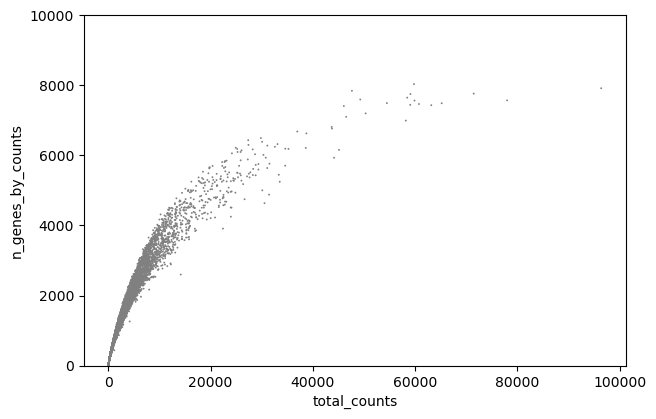

In [62]:
# Calculate qc metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
ax=sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', show=False)
ax.set_ylim(0,10000)

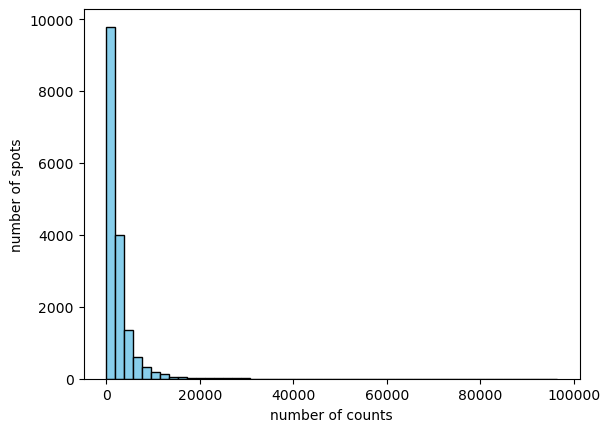

In [63]:
# Distribution of counts by spots
plt.hist(adata.obs['total_counts'], bins = 50, color='skyblue', edgecolor='black')
plt.xlabel('number of counts')
plt.ylabel('number of spots')
plt.show()

In [36]:
# Remove spots above the requested quantile of total counts (likely doublets/artifacts)
counts_threshold = adata.obs['total_counts'].quantile(counts_upper_quantile)
print(f"{counts_upper_quantile:.0%} quantile of total_counts: {counts_threshold:.0f}")
adata = adata[adata.obs['total_counts'] <= counts_threshold].copy()

99% quantile of total_counts: 18346


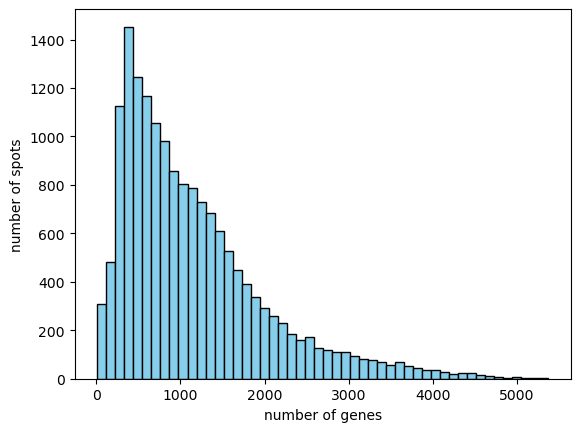

In [37]:
# Distribution of genes by spots
plt.hist(adata.obs['n_genes_by_counts'], bins = 50, color='skyblue', edgecolor='black')
plt.xlabel('number of genes')
plt.ylabel('number of spots')
plt.show()

In [64]:
# Remove spots with too few genes
sc.settings.verbosity = 3
sc.pp.filter_cells(adata, min_genes=min_genes_per_spot)

filtered out 618 cells that have less than 200 genes expressed


In [39]:
adata.obs.head()

,in_tissue,array_row,array_col,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,mt_frac,Barcode,total_counts_mt,pct_counts_mt,n_genes
spot_id,,,,,,,,,,,,,,,,,
Patient01_AAACAAGTATCTCCCA-1,1,50,102,Patient01,1175,7.085064,2134.0,7.763446,30.357143,41.369048,53.146259,70.535714,0.092687,Patient01_AAACAAGTATCTCCCA-1,0.0,0.0,1175
Patient01_AAACACCAATAACTGC-1,1,59,19,Patient01,842,6.754604,1575.0,7.469654,34.740445,47.689675,60.581860,79.634912,0.101540,Patient01_AAACACCAATAACTGC-1,0.0,0.0,842
Patient01_AAACAGGGTCTATATT-1,1,47,13,Patient01,575,6.376727,972.0,6.984716,35.681186,48.934198,64.133457,91.936979,0.099166,Patient01_AAACAGGGTCTATATT-1,0.0,0.0,575
Patient01_AAACATTTCCCGGATT-1,1,61,97,Patient01,2537,7.849324,8568.0,9.086590,33.401245,46.655348,57.792869,71.397849,0.030221,Patient01_AAACATTTCCCGGATT-1,0.0,0.0,2537
Patient01_AAACCGGGTAGGTACC-1,1,42,28,Patient01,1503,7.329750,3293.0,8.179481,31.379697,43.325855,54.374649,71.284352,0.076556,Patient01_AAACCGGGTAGGTACC-1,0.0,0.0,1503


In [ ]:
# Save the resulting raw filtered adata object
raw_adata_path.parent.mkdir(parents=True, exist_ok=True)
adata.write(raw_adata_path, compression="gzip")

### QC visualizations by sample

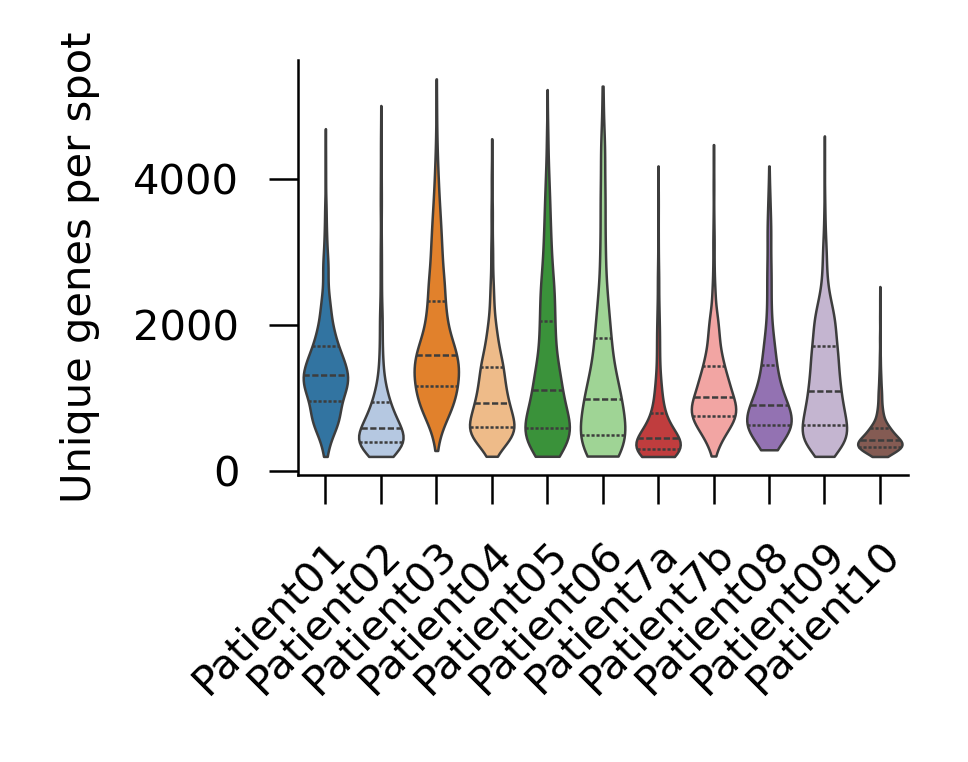

In [ ]:
# Plot number of transcripts and genes per spot per sample
figures_dir.mkdir(parents=True, exist_ok=True)

samples = adata.obs['sample'].unique()
colors = plt.cm.tab20(range(len(samples)))
color_map = dict(zip(samples, colors))
hex_colors = [mcolors.to_hex(color_map[sample]) for sample in samples]
palette = dict(zip(samples, hex_colors))


# Figure dimensions
fig_width_mm = 43.5
fig_width_inch = fig_width_mm / 25.4
fig_height_inch = fig_width_inch * 0.8

# Plot
fig, ax = plt.subplots(figsize=(fig_width_inch, fig_height_inch), dpi=600)
sns.violinplot(
    data=adata.obs,
    x='sample',
    y='n_genes_by_counts',
    order=samples,
    palette=palette,
    scale='width',
    inner='quart',
    cut=0,
    linewidth=0.3,
    width=0.8,
    ax=ax
)

# Style the plot
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(0.3)
ax.spines['bottom'].set_linewidth(0.3)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    rotation_mode='anchor',
    fontsize=5)

ax.tick_params(width=0.3, labelsize=5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('')
plt.ylabel(f'Unique genes per spot', fontsize=5)

plt.tight_layout()
plt.savefig(figures_dir / 'totalgenes_violin_by_sample.svg', dpi=600)
plt.show()

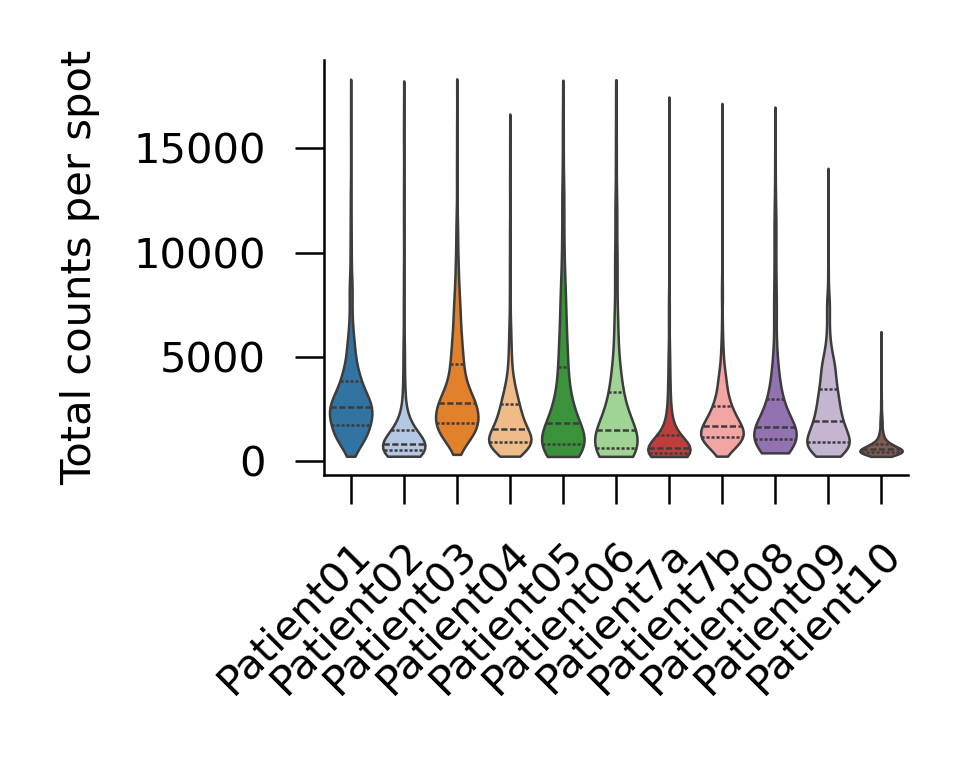

In [ ]:
fig, ax = plt.subplots(figsize=(fig_width_inch, fig_height_inch), dpi=600)
sns.violinplot(
    data=adata.obs,
    x='sample',
    y='total_counts',
    order=samples,
    palette=palette,
    scale='width',
    inner='quart',
    cut=0,
    linewidth=0.3,
    width=0.8,
    ax=ax
)

# Style the plot
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(0.3)
ax.spines['bottom'].set_linewidth(0.3)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    rotation_mode='anchor',
    fontsize=5)

ax.tick_params(width=0.3, labelsize=5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('')
plt.ylabel(f'Total counts per spot', fontsize=5)

plt.tight_layout()
plt.savefig(figures_dir / 'totalcounts_violin_by_sample.svg', dpi=600)
plt.show()

## Normalize

In [42]:
# Scale each cell to a common library size
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)

normalizing counts per cell
    finished (0:00:04)


In [43]:
sc.pp.log1p(adata)

In [ ]:
# Save the normalized file
normalized_adata_path.parent.mkdir(parents=True, exist_ok=True)
adata.write(normalized_adata_path, compression="gzip")

In [ ]:
# Read the normalized file
adata=anndata.read(normalized_adata_path)

# Stiffness data

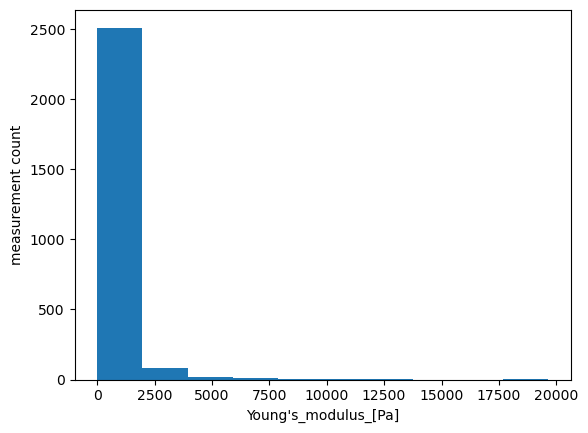

In [65]:
# Load the values after MAD/CV filtering (output of Measurements_processing.ipynb)
filtered_df=pd.read_csv(stiffness_measurements_tsv, sep='\t')
filtered_df["Young's_modulus_[Pa]"] = pd.to_numeric(filtered_df["Young's_modulus_[Pa]"])
# Plot the distribution of stiffness values
plt.hist(filtered_df["Young's_modulus_[Pa]"])
plt.xlabel("Young's_modulus_[Pa]")
plt.ylabel('measurement count')
plt.show()

In [66]:
filtered_df=filtered_df[filtered_df["Young's_modulus_[Pa]"] <= stiffness_upper_bound]

In [48]:
filtered_df.head()

,Sample,ROI,Position_Index,Young's_modulus_[Pa],ResidualRMS_[N],Spot X,Spot Y,AFM X,AFM Y,Distance_um,Barcode,x_final,y_final,std_x,std_y,x_dif,y_dif,Distance,Stable_0.5sigma,Annotation
0,Patient01,ROI01,3,41.7625,9.720000e-12,8406,5591,8360.397265,5609.976863,36.230933,Patient01_CGCCATCCGATTATGA-1,8360.291276,5609.708570,20.673675,20.677383,0.105989,0.268293,49.393631,True,Stroma
1,Patient01,ROI01,5,118.0150,1.270000e-11,8406,5591,8388.083373,5566.919343,22.016227,Patient01_CGCCATCCGATTATGA-1,8387.975696,5566.653553,20.928402,20.930842,0.107677,0.265790,30.014722,True,Stroma
2,Patient01,ROI01,6,69.7739,1.020000e-11,8406,5591,8401.926427,5545.390583,33.588329,Patient01_CGCCATCCGATTATGA-1,8401.817907,5545.126044,21.059048,21.061061,0.108521,0.264539,45.790970,True,Stroma
3,Patient01,ROI01,12,18.0129,9.460000e-12,8406,5591,8436.449503,5538.287066,44.653042,Patient01_CGCCATCCGATTATGA-1,8436.338937,5538.022900,21.106107,21.107481,0.110567,0.264166,60.875493,True,Stroma
4,Patient01,ROI01,14,21.4384,9.300000e-12,8406,5591,8408.763395,5581.344586,7.366739,Patient01_CGCCATCCGATTATGA-1,8408.654516,5581.077917,20.840947,20.842892,0.108879,0.266669,10.043075,True,Stroma


In [67]:
# Average of the stiffness for a spot, min and max values

# Perform the groupby and aggregate operations
stiff_df = (filtered_df.groupby('Barcode')
            .agg(mean=("Young's_modulus_[Pa]", 'mean'), 
                 min=("Young's_modulus_[Pa]", 'min'), 
                 max=("Young's_modulus_[Pa]", 'max'))
            .reset_index())

# Set Barcode as the index
stiff_df.set_index('Barcode', inplace=True)

In [50]:
stiff_df.head()

,mean,min,max
Barcode,,,
Patient01_AAGACTGCAAGCTACT-1,66.751272,9.27168,198.7550
Patient01_AAGTTGTGATGTTATA-1,32.678000,14.76940,59.9749
Patient01_ACGATACATAGAACTA-1,296.214167,92.15050,591.9430
Patient01_AGCCACTCCCGTGCTT-1,34.722050,18.27660,53.0649
Patient01_AGCGATGCGCCTAATA-1,93.542800,62.27980,132.5310


In [51]:
# Merging the dataframes, adding the columns from df to adata.obs
adata.obs = adata.obs.merge(stiff_df, left_on='Barcode', right_index=True, how='left')
adata = adata[~adata.obs['mean'].isna()].copy()

In [52]:
adata.obs

,in_tissue,array_row,array_col,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,mt_frac,Barcode,total_counts_mt,pct_counts_mt,n_genes,mean,min,max
spot_id,,,,,,,,,,,,,,,,,,,,
Patient01_AAGACTGCAAGCTACT-1,1,36,68,Patient01,1420,7.271704,2815.0,8.085794,33.138281,44.933785,55.836156,71.111796,0.133046,Patient01_AAGACTGCAAGCTACT-1,0.0,0.0,1420,66.751272,9.27168,198.7550
Patient01_AAGTTGTGATGTTATA-1,1,66,106,Patient01,2497,7.831617,5748.0,8.680332,21.104503,31.486831,43.364486,60.050977,0.023280,Patient01_AAGTTGTGATGTTATA-1,0.0,0.0,2497,32.678000,14.76940,59.9749
Patient01_ACGATACATAGAACTA-1,1,22,80,Patient01,2009,7.616776,4932.0,8.630165,34.375558,46.006789,56.405217,70.037520,0.118814,Patient01_ACGATACATAGAACTA-1,0.0,0.0,2009,296.214167,92.15050,591.9430
Patient01_AGCCACTCCCGTGCTT-1,1,23,81,Patient01,1993,7.611348,4954.0,8.650499,33.841036,46.165966,56.985294,70.605742,0.132703,Patient01_AGCCACTCCCGTGCTT-1,0.0,0.0,1993,34.722050,18.27660,53.0649
Patient01_AGCGATGCGCCTAATA-1,1,64,108,Patient01,2815,7.951559,7486.0,8.956093,24.722724,35.865360,47.227238,62.419396,0.034563,Patient01_AGCGATGCGCCTAATA-1,0.0,0.0,2815,93.542800,62.27980,132.5310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Patient10_TGATACATTTAGCCGT-1,1,55,43,Patient10,540,6.320768,727.0,6.708084,32.151589,44.376528,56.601467,93.276284,0.111247,Patient10_TGATACATTTAGCCGT-1,0.0,0.0,540,246.719720,78.68420,615.2990
Patient10_TGTAGTGATCTATAAT-1,1,35,33,Patient10,299,5.743003,359.0,6.016157,36.185819,48.410758,72.860636,100.000000,0.122249,Patient10_TGTAGTGATCTATAAT-1,0.0,0.0,299,1073.699050,13.92860,2930.8100
Patient10_TTGACTACCATATGGT-1,1,43,41,Patient10,846,6.762730,1312.0,7.242083,31.733524,40.257880,52.435530,73.925501,0.060172,Patient10_TTGACTACCATATGGT-1,0.0,0.0,846,173.684967,93.51080,365.0030


In [53]:
# Remove genes found in fewer than min_spots_per_gene spots
sc.pp.filter_genes(adata, min_cells=min_spots_per_gene)

filtered out 28217 genes that are detected in less than 10 cells


In [54]:
# Count spots per sample
adata.obs['sample'].value_counts()

sample
Patient05    38
Patient7b    38
Patient03    33
Patient06    32
Patient10    32
Patient01    31
Patient7a    23
Patient08    23
Patient04    20
Patient02    18
Patient09     9
Name: count, dtype: int64

In [55]:
exclude_genes = adata.var['rp'].values
# Filter out RP genes from adata
adataex = adata[:, ~exclude_genes]
# Create df with barcodes and genes
adataex.var['SYMBOL']=adataex.var.index
df = pd.DataFrame(adataex.X.toarray(), columns=adataex.var['SYMBOL'], index=adataex.obs['Barcode'])
# Add stiffness values
df1=pd.merge(df, stiff_df, how='inner', on='Barcode')

In [56]:
df1.head()

,NOC2L,HES4,ISG15,AGRN,C1orf159,AL390719.2,SDF4,B3GALT6,UBE2J2,ACAP3,...,FUNDC2,CMC4,BRCC3,VBP1,VAMP7,DDX3Y,EIF1AY,mean,min,max
Barcode,,,,,,,,,,,,,,,,,,,,,
Patient01_AAGACTGCAAGCTACT-1,1.515654,0.000000,1.515654,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,66.751272,9.27168,198.7550
Patient01_AAGTTGTGATGTTATA-1,0.000000,1.499505,1.827642,0.000000,0.0,0.0,1.007861,0.0,0.000000,1.007861,...,0.000000,0.0,0.000000,0.000000,1.007861,0.0,0.0,32.678000,14.76940,59.9749
Patient01_ACGATACATAGAACTA-1,1.620408,0.000000,1.107762,1.107762,0.0,0.0,0.000000,0.0,1.107762,1.107762,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,296.214167,92.15050,591.9430
Patient01_AGCCACTCCCGTGCTT-1,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,1.104784,0.000000,...,1.616839,0.0,0.000000,1.104784,0.000000,0.0,0.0,34.722050,18.27660,53.0649
Patient01_AGCGATGCGCCTAATA-1,1.300642,1.300642,1.610933,0.000000,0.0,0.0,0.848366,0.0,0.000000,0.000000,...,1.300642,0.0,0.848366,0.848366,0.000000,0.0,0.0,93.542800,62.27980,132.5310


In [ ]:
normalized_merged_tsv.parent.mkdir(parents=True, exist_ok=True)
df1.to_csv(normalized_merged_tsv, sep='\t')

# Export data for DE analysis

In [68]:
# Raw counts are used here
#adata=anndata.read(raw_adata_path)
adata.obs = adata.obs.merge(stiff_df, left_on='Barcode', right_index=True, how='left')
adata = adata[~adata.obs['mean'].isna()].copy()
sc.pp.filter_genes(adata, min_cells=min_spots_per_gene)
exclude_genes = adata.var['rp'].values
adata = adata[:, ~exclude_genes]

filtered out 28217 genes that are detected in less than 10 cells


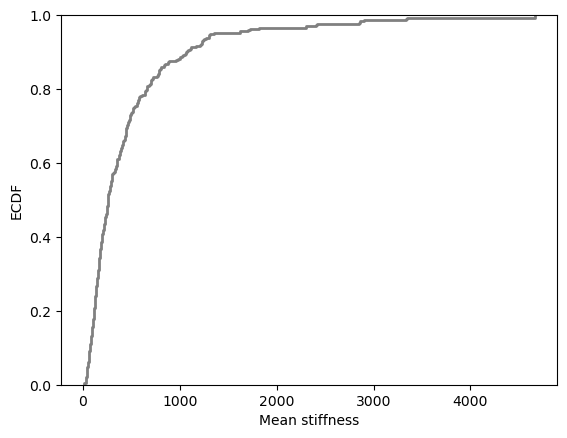

In [69]:
# Identify stiffness thresholds
sns.ecdfplot(adata.obs['mean'], linewidth=2, color='gray')
plt.xlabel('Mean stiffness')
plt.ylabel('ECDF')
plt.show()

In [70]:
# For reference: the de_thresholds above are chosen relative to roughly the median stiffness
median_stiffness = np.quantile(adata.obs['mean'], 0.5)
print(f"Median stiffness: {median_stiffness:.1f}")

Median stiffness: 258.2


In [ ]:
# For each threshold, split spots into ECM_low / ECM_high and export counts + metadata for DE analysis in R
de_output_dir.mkdir(parents=True, exist_ok=True)

for threshold in de_thresholds:
    adata1 = adata.copy()

    condition_ecm_low = adata1.obs['mean'] <= threshold
    condition_ecm_high = adata1.obs['mean'] > threshold

    # Apply the conditions to create the new column
    adata1.obs['Barcode_DE'] = np.where(condition_ecm_low, 'ECM_low', np.where(condition_ecm_high, 'ECM_high', 'none'))

    print(f"Threshold {threshold}:")
    print(adata1.obs['Barcode_DE'].value_counts())

    # Remove NaNs
    adata1 = adata1[adata1.obs['Barcode_DE'] != 'none'].copy()

    # Save the data for analysis in R:
    # Save the counts matrix (assay)
    counts_df = pd.DataFrame(adata1.X.T.todense(), index=adata1.var_names, columns=adata1.obs_names)
    counts_df.to_csv(de_output_dir / f"counts_{threshold}.csv")

    # Save metadata (colData)
    adata1.obs.to_csv(de_output_dir / f"coldata_{threshold}.csv")

    # Save variable metadata (rowData)
    adata1.var.to_csv(de_output_dir / f"rowdata_{threshold}.csv")